# Safety Framework — Bayesian Trajectory Prediction
**Uncertainty-aware safety decisions for autonomous driving**

Models evaluated on ZARA2 (held-out test scene)
- MC Dropout: Best FDE 0.8892
- Variational BNN: Best FDE 1.0315

In [2]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import pyro
import os, sys

# Point to project root
sys.path.append(os.path.abspath('..'))

from src.data_loader import ScenesDataLoader
from mc_dropout.mcmc import MCDropoutLSTM, mc_predict
from variational_bnn.bnn import VariationalLSTM, BayesianTrajectoryPredictor, vbnn_predict

from torch.distributions import constraints
torch.serialization.add_safe_globals([constraints._Real])


# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
pyro.set_rng_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('plots', exist_ok=True)
print(f'Using device: {device}')

/Users/khadijahlawal/Projects/bayesian-trajectory-prediction/btp-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 1. Load Data

In [3]:
loader = ScenesDataLoader(data_root='../data/raw/')
test_loader = loader.get_test_loader() 


print(f'Test samples: {len(test_loader.dataset)}')

# Grab a batch for all analyses
batch = next(iter(test_loader))
obs, gt = batch[0].to(device), batch[1].to(device)
print(f'obs shape: {obs.shape}')   # (32, 8, 2)
print(f'gt  shape: {gt.shape}')    # (32, 12, 2)

Test samples: 34161
obs shape: torch.Size([32, 8, 2])
gt  shape: torch.Size([32, 12, 2])


## 2. Load Models

In [4]:
# MC Dropout
mc_model = MCDropoutLSTM(
    input_dim=2, hidden_dim=128, pred_len=12, num_layers=2, dropout_p=0.3
).to(device)
mc_model.load_state_dict(
    torch.load('../mc_dropout/models/mc_dropout_best.pt', map_location=device)
)
print('MC Dropout loaded')

# Variational BNN
vbnn_lstm = VariationalLSTM(
    input_dim=2, hidden_dim=128, pred_len=12, num_layers=2, dropout_p=0.1
).to(device)
vbnn_lstm.load_state_dict(
    torch.load('../variational_bnn/models/vbnn_best.pt', map_location=device)
)

pyro.get_param_store().load(
    '../variational_bnn/models/vbnn_params.pt', map_location=device
)

bayes_predictor = BayesianTrajectoryPredictor(vbnn_lstm, device)
print('Variational BNN loaded')


MC Dropout loaded
Variational BNN loaded


## 3. Run Predictions

In [5]:
N_SAMPLES = 50

mc_mean, mc_var, mc_samples   = mc_predict(mc_model, obs, n_samples=N_SAMPLES)
vb_mean, vb_var, vb_samples   = vbnn_predict(vbnn_lstm, bayes_predictor, obs, n_samples=N_SAMPLES)

print(f'MC  mean: {mc_mean.shape}, var: {mc_var.shape}, samples: {mc_samples.shape}')
print(f'VB  mean: {vb_mean.shape}, var: {vb_var.shape}, samples: {vb_samples.shape}')

MC  mean: torch.Size([32, 12, 2]), var: torch.Size([32, 12, 2]), samples: torch.Size([50, 32, 12, 2])
VB  mean: torch.Size([32, 12, 2]), var: torch.Size([32, 12, 2]), samples: torch.Size([50, 32, 12, 2])


## 4. Safety Scores & Classification

In [6]:
# Thresholds calibrated to MC Dropout uncertainty scale
MC_LOW    = 0.020   # below -> SAFE
MC_HIGH   = 0.040   # above -> UNSAFE

# Variational BNN has lower uncertainty scale (~0.003)
VB_LOW    = 0.002
VB_HIGH   = 0.004

def compute_safety_score(variance, high_threshold):
    """Safety score in [0,1]. 1.0 = fully safe."""
    mean_unc = variance.mean(dim=(1, 2))  # (B,)
    scores   = 1.0 - torch.clamp(mean_unc / high_threshold, 0.0, 1.0)
    return scores

def classify_safety(variance, low_threshold, high_threshold):
    mean_unc = variance.mean(dim=(1, 2))
    scores   = compute_safety_score(variance, high_threshold)
    labels   = []
    for u in mean_unc:
        u = u.item()
        if   u < low_threshold:  labels.append('SAFE')
        elif u < high_threshold: labels.append('CAUTION')
        else:                    labels.append('UNSAFE')
    return labels, scores

mc_labels, mc_scores = classify_safety(mc_var, MC_LOW, MC_HIGH)
vb_labels, vb_scores = classify_safety(vb_var, VB_LOW, VB_HIGH)

for name, labels, scores in [('MC Dropout', mc_labels, mc_scores),
                               ('Variational BNN', vb_labels, vb_scores)]:
    print(f'\n{name}')
    print(f'  SAFE:    {labels.count("SAFE")}')
    print(f'  CAUTION: {labels.count("CAUTION")}')
    print(f'  UNSAFE:  {labels.count("UNSAFE")}')
    print(f'  Mean score: {scores.mean():.3f}')


MC Dropout
  SAFE:    22
  CAUTION: 2
  UNSAFE:  8
  Mean score: 0.654

Variational BNN
  SAFE:    23
  CAUTION: 2
  UNSAFE:  7
  Mean score: 0.485


## 5. Plot 1 — Trajectory Predictions with Uncertainty Fans

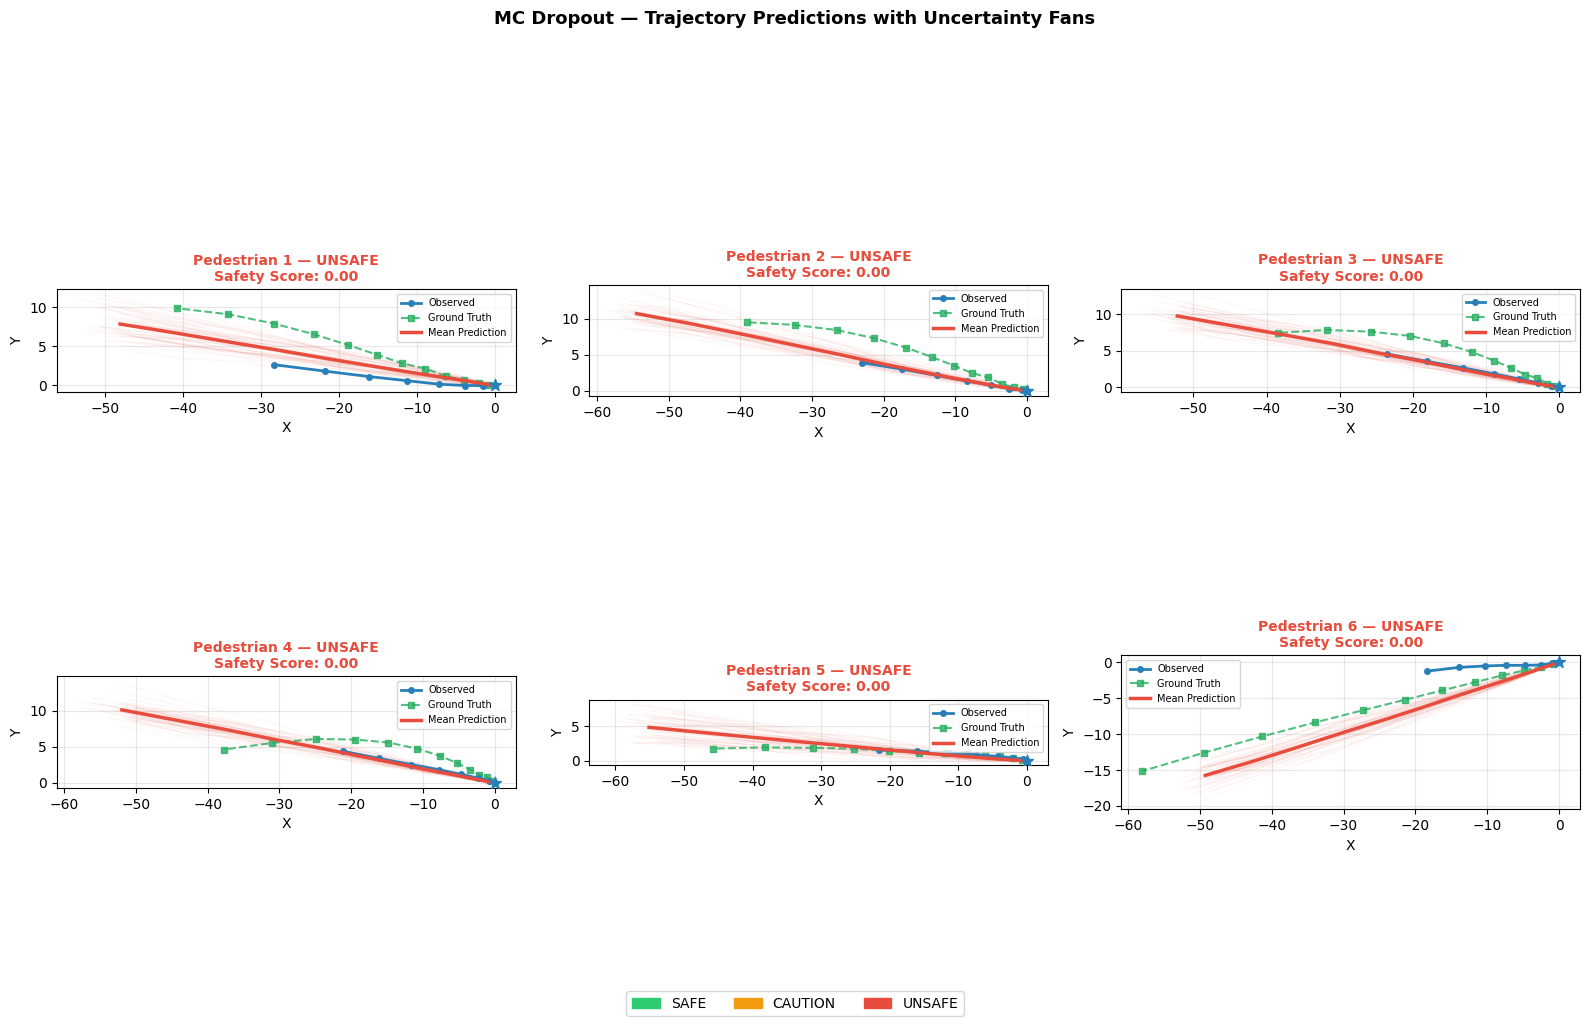

In [14]:
def plot_uncertainty_fans(obs, gt, mean, samples, labels, scores, model_name, n_display=6):
    """
    Plot trajectory predictions with uncertainty fans.
    Each fan shows the spread of individual MC samples around the mean.
    """
    n_display = min(n_display, obs.size(0))
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()
    color_map = {'SAFE': '#2ecc71', 'CAUTION': '#f39c12', 'UNSAFE': '#e74c3c'}

    for i in range(n_display):
        ax     = axes[i]
        label  = labels[i]
        score  = scores[i].item()
        color  = color_map[label]

        # Cumsum: relative displacements -> absolute positions
        obs_abs    = obs[i].cpu().cumsum(0).numpy()          # (8, 2)
        gt_abs     = gt[i].cpu().cumsum(0).numpy()           # (12, 2)
        mean_abs   = mean[i].cpu().cumsum(0).numpy()         # (12, 2)
        # Individual sample trajectories for fan
        samp_abs   = samples[:, i, :, :].cpu().cumsum(1).numpy()  # (N, 12, 2)

        # Fan: plot each sample faintly
        for s in range(samp_abs.shape[0]):
            ax.plot(samp_abs[s, :, 0], samp_abs[s, :, 1],
                    color=color, alpha=0.05, linewidth=0.8)

        # Observed
        ax.plot(obs_abs[:, 0], obs_abs[:, 1],
                'o-', color='#2980b9', markersize=4, linewidth=2, label='Observed', zorder=5)
        # Ground truth
        ax.plot(gt_abs[:, 0], gt_abs[:, 1],
                's--', color='#27ae60', markersize=4, linewidth=1.5, label='Ground Truth', alpha=0.8, zorder=4)
        # Predicted mean
        ax.plot(mean_abs[:, 0], mean_abs[:, 1],
                '-', color=color, linewidth=2.5, label=f'Mean Prediction', zorder=6)
        # Start marker
        ax.scatter(obs_abs[0, 0], obs_abs[0, 1], color='#2980b9', s=80, zorder=7, marker='*')

        ax.set_title(f'Pedestrian {i+1} — {label}\nSafety Score: {score:.2f}',
                     color=color, fontweight='bold', fontsize=10)
        ax.legend(fontsize=7, loc='best')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')

    safe_patch    = mpatches.Patch(color='#2ecc71', label='SAFE')
    caution_patch = mpatches.Patch(color='#f39c12', label='CAUTION')
    unsafe_patch  = mpatches.Patch(color='#e74c3c', label='UNSAFE')
    fig.legend(handles=[safe_patch, caution_patch, unsafe_patch],
               loc='lower center', ncol=3, fontsize=10, frameon=True)

    fig.suptitle(f'{model_name} — Trajectory Predictions with Uncertainty Fans',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'plots/{model_name.lower().replace(" ", "_")}_uncertainty_fans.png',
                dpi=150, bbox_inches='tight')
    plt.show()

plot_uncertainty_fans(obs, gt, mc_mean, mc_samples, mc_labels, mc_scores, 'MC Dropout')

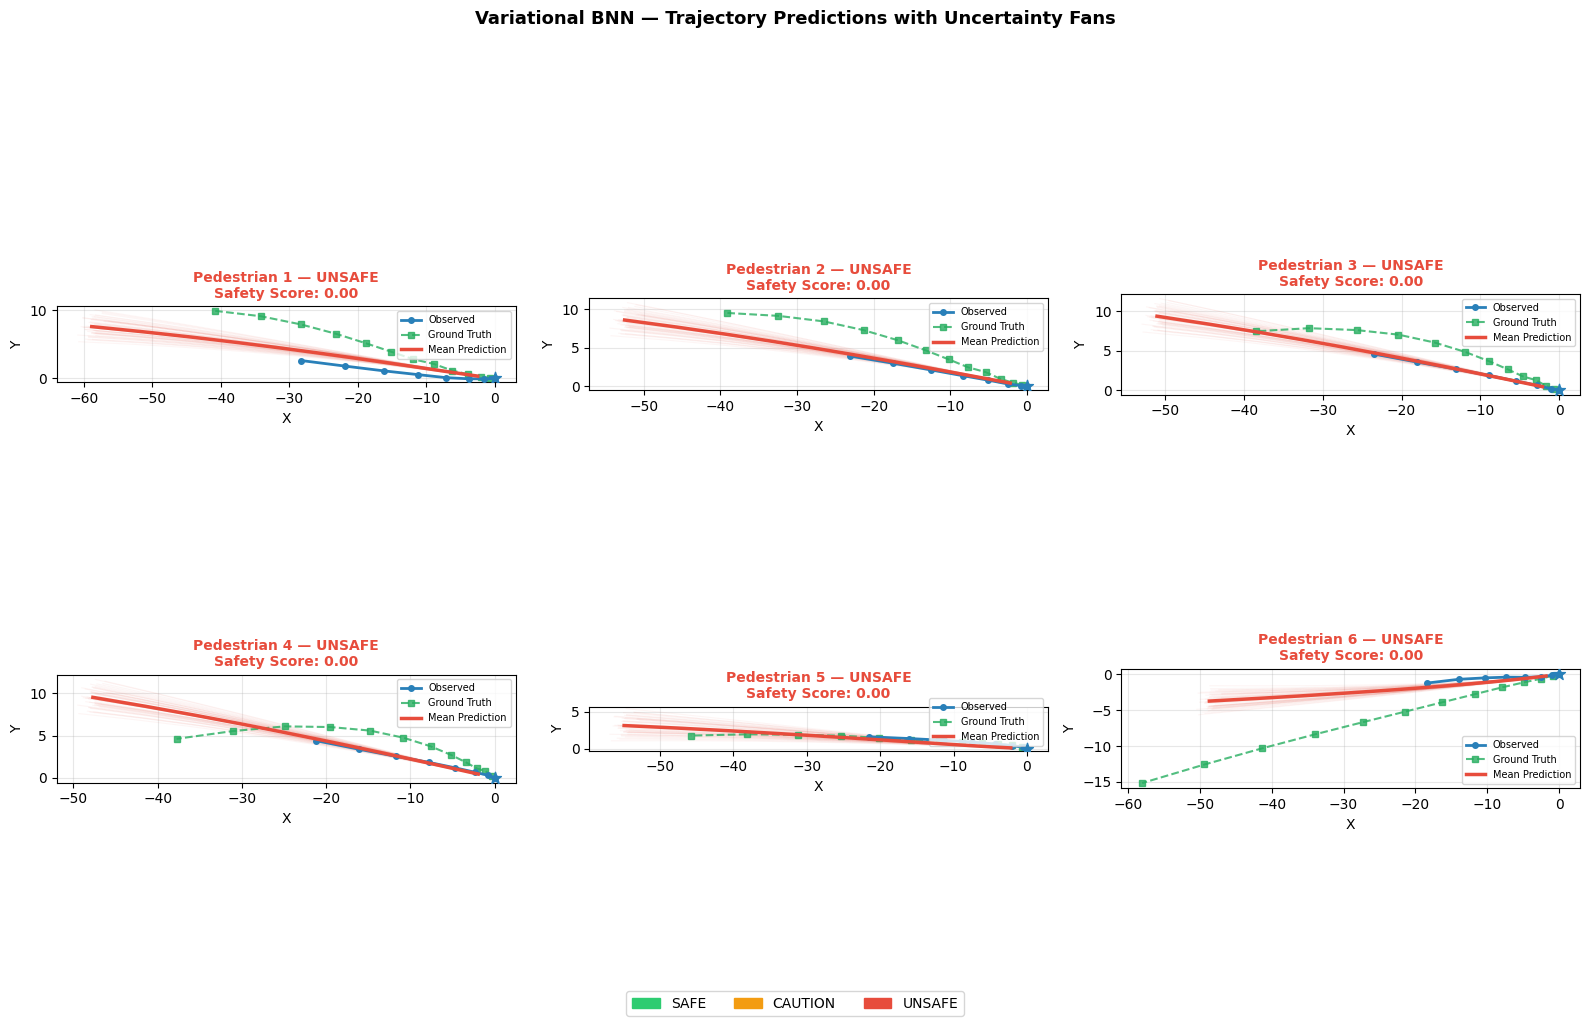

In [15]:
plot_uncertainty_fans(obs, gt, vb_mean, vb_samples, vb_labels, vb_scores, 'Variational BNN')

## 6. Plot 2 — Uncertainty Over Prediction Horizon

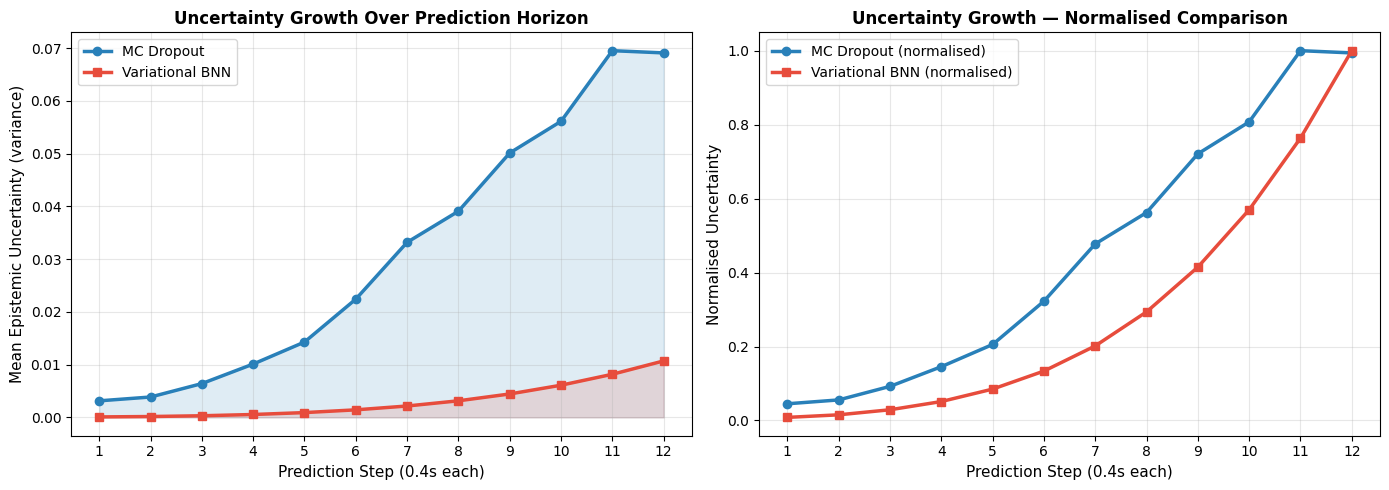

In [8]:
def plot_uncertainty_over_time(mc_var, vb_var):
    """
    Show how uncertainty grows across the 12 prediction steps.
    Key insight: uncertainty should increase for longer horizons.
    """
    # Mean uncertainty per timestep across batch and both axes
    mc_unc_time = mc_var.mean(dim=(0, 2)).cpu().numpy()   # (12,)
    vb_unc_time = vb_var.mean(dim=(0, 2)).cpu().numpy()   # (12,)
    steps = np.arange(1, 13)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: raw uncertainty per step ──
    axes[0].plot(steps, mc_unc_time, 'o-', color='#2980b9',
                 linewidth=2.5, markersize=6, label='MC Dropout')
    axes[0].plot(steps, vb_unc_time, 's-', color='#e74c3c',
                 linewidth=2.5, markersize=6, label='Variational BNN')
    axes[0].fill_between(steps, mc_unc_time, alpha=0.15, color='#2980b9')
    axes[0].fill_between(steps, vb_unc_time, alpha=0.15, color='#e74c3c')
    axes[0].set_xlabel('Prediction Step (0.4s each)', fontsize=11)
    axes[0].set_ylabel('Mean Epistemic Uncertainty (variance)', fontsize=11)
    axes[0].set_title('Uncertainty Growth Over Prediction Horizon', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(steps)

    # ── Right: normalised (0-1) for direct shape comparison ──
    mc_norm = mc_unc_time / mc_unc_time.max()
    vb_norm = vb_unc_time / vb_unc_time.max()
    axes[1].plot(steps, mc_norm, 'o-', color='#2980b9',
                 linewidth=2.5, markersize=6, label='MC Dropout (normalised)')
    axes[1].plot(steps, vb_norm, 's-', color='#e74c3c',
                 linewidth=2.5, markersize=6, label='Variational BNN (normalised)')
    axes[1].set_xlabel('Prediction Step (0.4s each)', fontsize=11)
    axes[1].set_ylabel('Normalised Uncertainty', fontsize=11)
    axes[1].set_title('Uncertainty Growth — Normalised Comparison', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(steps)

    plt.tight_layout()
    plt.savefig('plots/uncertainty_over_time.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_uncertainty_over_time(mc_var, vb_var)

## 7. Plot 3 — Calibration Plots

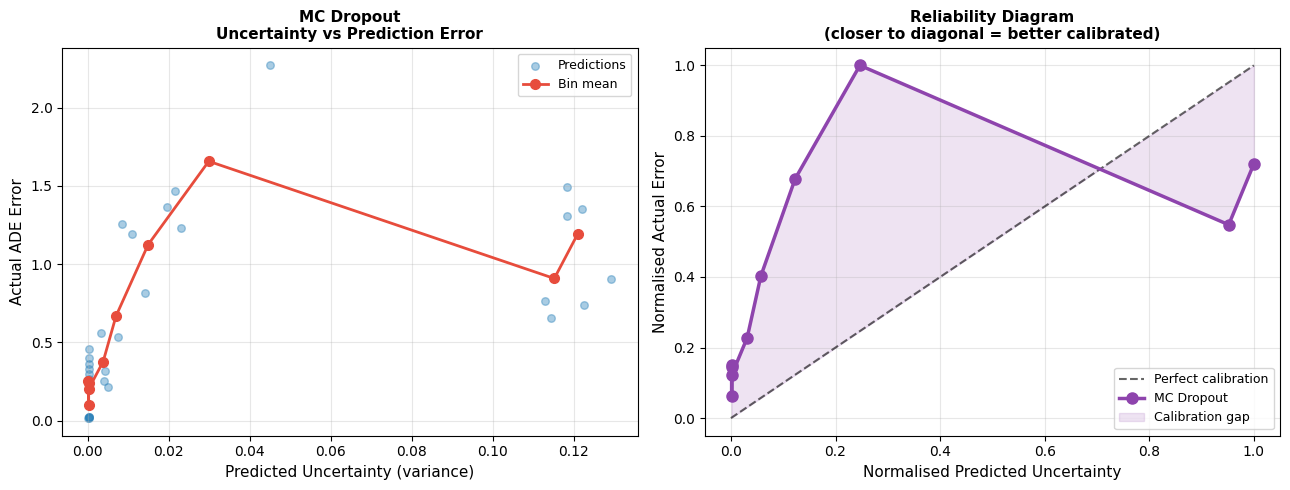

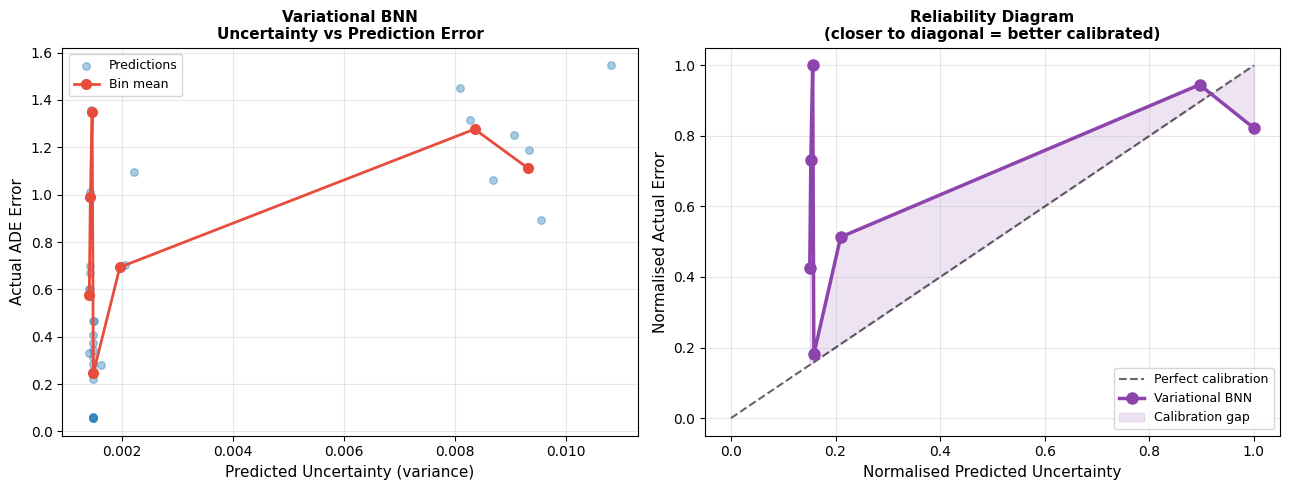

In [9]:
def plot_calibration(mean, variance, gt, model_name, n_bins=10):
    """
    Calibration: if the model is well-calibrated, its predicted uncertainty
    should correlate with actual prediction error.
    A well-calibrated model has a near-diagonal calibration curve.
    """
    # Per-sample mean uncertainty and ADE error
    unc   = variance.mean(dim=(1, 2)).cpu().numpy()         # (B,)
    error = torch.norm(mean - gt, dim=-1).mean(dim=1)       # (B,)
    error = error.cpu().numpy()

    # Bin by uncertainty, compute mean error per bin
    bins        = np.percentile(unc, np.linspace(0, 100, n_bins + 1))
    bin_centers, bin_errors, bin_uncs = [], [], []

    for j in range(n_bins):
        mask = (unc >= bins[j]) & (unc < bins[j + 1])
        if mask.sum() > 0:
            bin_centers.append(unc[mask].mean())
            bin_errors.append(error[mask].mean())
            bin_uncs.append(unc[mask].mean())

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # ── Left: uncertainty vs error scatter ──
    axes[0].scatter(unc, error, alpha=0.4, color='#2980b9', s=30, label='Predictions')
    axes[0].plot(bin_centers, bin_errors, 'o-', color='#e74c3c',
                 linewidth=2, markersize=7, label='Bin mean')
    axes[0].set_xlabel('Predicted Uncertainty (variance)', fontsize=11)
    axes[0].set_ylabel('Actual ADE Error', fontsize=11)
    axes[0].set_title(f'{model_name}\nUncertainty vs Prediction Error', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # ── Right: reliability diagram ──
    # Normalise both to [0,1] for diagonal comparison
    bc_norm = np.array(bin_centers)
    be_norm = np.array(bin_errors)
    if bc_norm.max() > 0: bc_norm = bc_norm / bc_norm.max()
    if be_norm.max() > 0: be_norm = be_norm / be_norm.max()

    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect calibration', alpha=0.6)
    axes[1].plot(bc_norm, be_norm, 'o-', color='#8e44ad',
                 linewidth=2.5, markersize=8, label=model_name)
    axes[1].fill_between(bc_norm, be_norm, bc_norm, alpha=0.15, color='#8e44ad',
                          label='Calibration gap')
    axes[1].set_xlabel('Normalised Predicted Uncertainty', fontsize=11)
    axes[1].set_ylabel('Normalised Actual Error', fontsize=11)
    axes[1].set_title('Reliability Diagram\n(closer to diagonal = better calibrated)',
                      fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'plots/{model_name.lower().replace(" ", "_")}_calibration.png',
                dpi=150, bbox_inches='tight')
    plt.show()

plot_calibration(mc_mean, mc_var, gt, 'MC Dropout')
plot_calibration(vb_mean, vb_var, gt, 'Variational BNN')

## 8. Plot 4 — Comparison Table

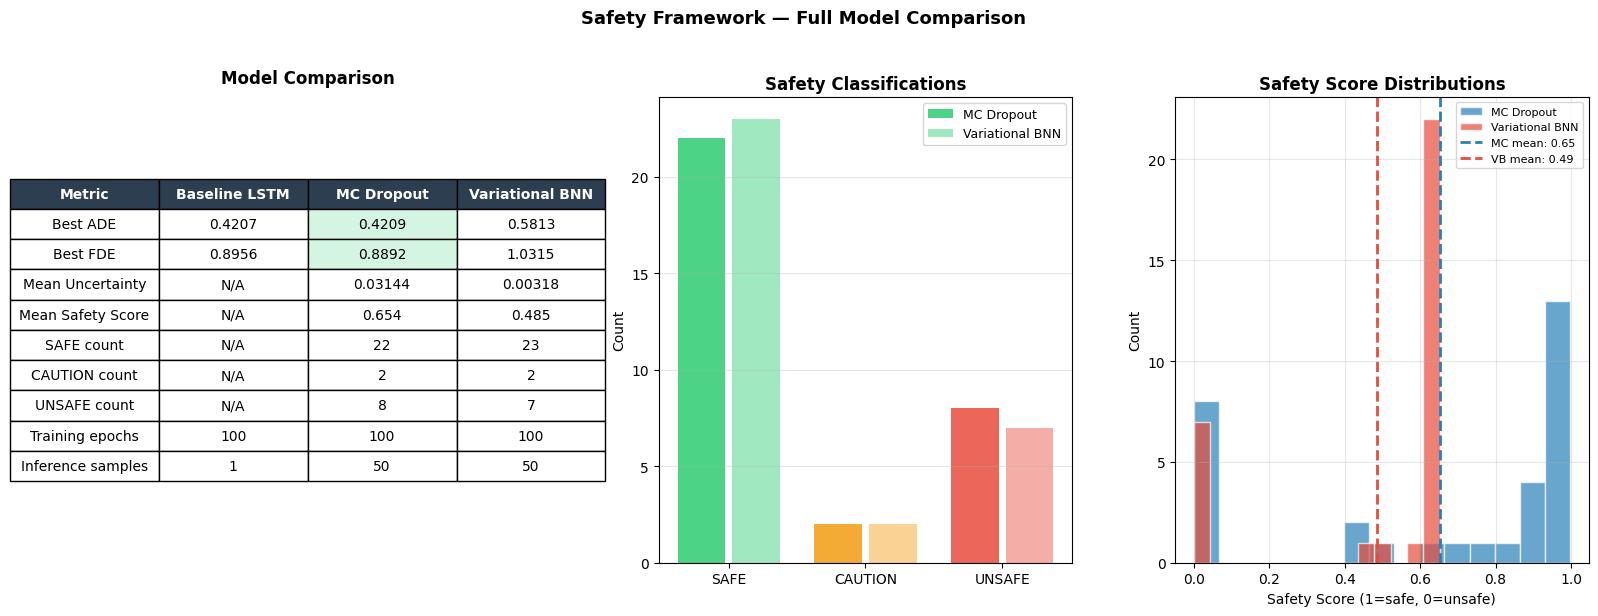

In [13]:
def plot_comparison_table(mc_labels, vb_labels, mc_scores, vb_scores, mc_var, vb_var):
    fig = plt.figure(figsize=(16, 6))
    gs  = gridspec.GridSpec(1, 3, width_ratios=[1.2, 1, 1])

    # ── Metrics table ──
    ax_table = fig.add_subplot(gs[0])
    ax_table.axis('off')
    
    table_data = [
        ['Metric',            'Baseline LSTM', 'MC Dropout',                       'Variational BNN'],
        ['Best ADE',          '0.4207',        '0.4209',                           '0.5813'],
        ['Best FDE',          '0.8956',        '0.8892',                           '1.0315'],
        ['Mean Uncertainty',  'N/A',           f"{mc_var.mean():.5f}",             f"{vb_var.mean():.5f}"],
        ['Mean Safety Score', 'N/A',           f"{mc_scores.mean():.3f}",          f"{vb_scores.mean():.3f}"],
        ['SAFE count',        'N/A',           str(mc_labels.count('SAFE')),       str(vb_labels.count('SAFE'))],
        ['CAUTION count',     'N/A',           str(mc_labels.count('CAUTION')),    str(vb_labels.count('CAUTION'))],
        ['UNSAFE count',      'N/A',           str(mc_labels.count('UNSAFE')),     str(vb_labels.count('UNSAFE'))],
        ['Training epochs',   '100',           '100',                              '100'],
        ['Inference samples', '1',             '50',                               '50'],
    ]

    t = ax_table.table(
        cellText=table_data[1:],
        colLabels=table_data[0],
        cellLoc='center', loc='center'
    )
    t.auto_set_font_size(False)
    t.set_fontsize(10)
    t.scale(1.2, 1.8)
    # Header styling
    for j in range(4):
        t[0, j].set_facecolor('#2c3e50')
        t[0, j].set_text_props(color='white', fontweight='bold')
    # Highlight best values
    for row in [1, 2]:  # ADE, FDE rows
        t[row, 2].set_facecolor('#d5f5e3')  # MC Dropout column is now index 2
    ax_table.set_title('Model Comparison', fontweight='bold', fontsize=12, pad=10)

    # ── Safety classification bar chart ──
    ax_bar = fig.add_subplot(gs[1])
    categories = ['SAFE', 'CAUTION', 'UNSAFE']
    colors     = ['#2ecc71', '#f39c12', '#e74c3c']
    mc_counts  = [mc_labels.count(c) for c in categories]
    vb_counts  = [vb_labels.count(c) for c in categories]
    x = np.arange(len(categories))

    ax_bar.bar(x - 0.2, mc_counts, 0.35, label='MC Dropout',     color=colors, alpha=0.85)
    ax_bar.bar(x + 0.2, vb_counts, 0.35, label='Variational BNN', color=colors, alpha=0.45)
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(categories, fontsize=10)
    ax_bar.set_ylabel('Count', fontsize=10)
    ax_bar.set_title('Safety Classifications', fontweight='bold', fontsize=12)
    ax_bar.legend(fontsize=9)
    ax_bar.grid(True, alpha=0.3, axis='y')

    # ── Safety score distributions ──
    ax_hist = fig.add_subplot(gs[2])
    ax_hist.hist(mc_scores.cpu().numpy(), bins=15, alpha=0.7,
                 color='#2980b9', label='MC Dropout', edgecolor='white')
    ax_hist.hist(vb_scores.cpu().numpy(), bins=15, alpha=0.7,
                 color='#e74c3c', label='Variational BNN', edgecolor='white')
    ax_hist.axvline(mc_scores.mean().item(), color='#2980b9',
                    linestyle='--', linewidth=2, label=f'MC mean: {mc_scores.mean():.2f}')
    ax_hist.axvline(vb_scores.mean().item(), color='#e74c3c',
                    linestyle='--', linewidth=2, label=f'VB mean: {vb_scores.mean():.2f}')
    ax_hist.set_xlabel('Safety Score (1=safe, 0=unsafe)', fontsize=10)
    ax_hist.set_ylabel('Count', fontsize=10)
    ax_hist.set_title('Safety Score Distributions', fontweight='bold', fontsize=12)
    ax_hist.legend(fontsize=8)
    ax_hist.grid(True, alpha=0.3)

    plt.suptitle('Safety Framework — Full Model Comparison', fontsize=13,
                 fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('plots/comparison_table.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_comparison_table(mc_labels, vb_labels, mc_scores, vb_scores, mc_var, vb_var)

## 9. ETH Crossing Scenario
Simulated scenario: pedestrian path crosses an autonomous vehicle's planned route.
High uncertainty = vehicle should slow down or yield.

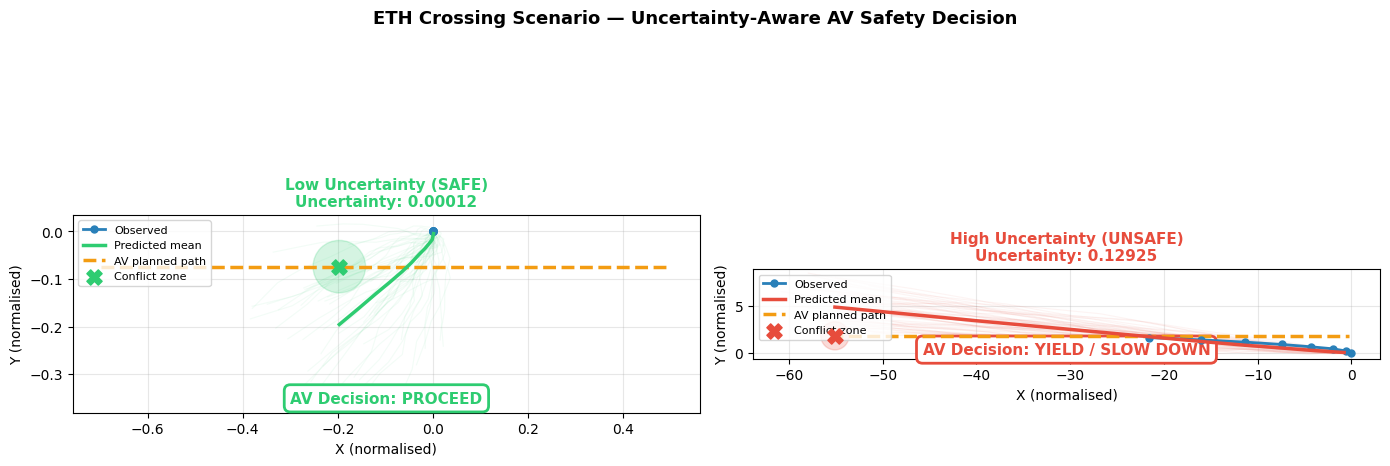

In [11]:
def plot_crossing_scenario(obs, mc_mean, mc_var, mc_samples, idx=0):
    """
    Simulate an AV crossing scenario.
    - Pedestrian trajectory predicted with uncertainty fan
    - AV path shown as a fixed straight line
    - Highlight the conflict zone where paths may intersect
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax_i, (ax, title) in enumerate(zip(axes, ['Low Uncertainty (SAFE)', 'High Uncertainty (UNSAFE)'])):
        # Pick a sample with matching safety label if possible
        unc_per_sample = mc_var.mean(dim=(1, 2)).cpu().numpy()
        if ax_i == 0:
            i = int(np.argmin(unc_per_sample))   # most certain
        else:
            i = int(np.argmax(unc_per_sample))   # most uncertain

        obs_abs  = obs[i].cpu().cumsum(0).numpy()
        mean_abs = mc_mean[i].cpu().cumsum(0).numpy()
        samp_abs = mc_samples[:, i, :, :].cpu().cumsum(1).numpy()

        # AV path: straight horizontal line through the scene
        av_x = np.linspace(mean_abs[:, 0].min() - 0.5, mean_abs[:, 0].max() + 0.5, 100)
        av_y = np.full_like(av_x, mean_abs[:, 1].mean())

        # Fan
        color = '#2ecc71' if ax_i == 0 else '#e74c3c'
        for s in range(samp_abs.shape[0]):
            ax.plot(samp_abs[s, :, 0], samp_abs[s, :, 1],
                    color=color, alpha=0.06, linewidth=0.8)

        # Observed + predicted
        ax.plot(obs_abs[:, 0], obs_abs[:, 1], 'o-',
                color='#2980b9', linewidth=2, markersize=5, label='Observed', zorder=5)
        ax.plot(mean_abs[:, 0], mean_abs[:, 1], '-',
                color=color, linewidth=2.5, label='Predicted mean', zorder=6)

        # AV path
        ax.plot(av_x, av_y, '--', color='#f39c12', linewidth=2.5,
                label='AV planned path', zorder=4)

        # Conflict zone: circle at mean predicted endpoint
        std_final = mc_var[i, -1].mean().sqrt().item()
        conflict  = plt.Circle((mean_abs[-1, 0], av_y[50]),
                                std_final * 3, color=color, alpha=0.2, zorder=3)
        ax.add_patch(conflict)
        ax.scatter(mean_abs[-1, 0], av_y[50], color=color,
                   s=120, zorder=8, marker='X', label='Conflict zone')

        # Decision banner
        decision = 'PROCEED' if ax_i == 0 else 'YIELD / SLOW DOWN'
        ax.text(0.5, 0.05, f'AV Decision: {decision}',
                transform=ax.transAxes, ha='center', fontsize=11,
                fontweight='bold', color=color,
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor=color, linewidth=2))

        unc_val = unc_per_sample[i]
        ax.set_title(f'{title}\nUncertainty: {unc_val:.5f}',
                     fontweight='bold', fontsize=11, color=color)
        ax.legend(fontsize=8, loc='upper left')
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('X (normalised)')
        ax.set_ylabel('Y (normalised)')

    fig.suptitle('ETH Crossing Scenario — Uncertainty-Aware AV Safety Decision',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/crossing_scenario.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_crossing_scenario(obs, mc_mean, mc_var, mc_samples)

## 10. Summary
Key findings from the safety framework analysis.

In [12]:
print('=' * 55)
print('SAFETY FRAMEWORK SUMMARY')
print('=' * 55)

print(f'\nModel Performance (ZARA2 test set):')
print(f'  MC Dropout     — ADE: 0.4209  FDE: 0.8892')
print(f'  Variational BNN — ADE: 0.5813  FDE: 1.0315')

print(f'\nSafety Classifications (batch of {obs.size(0)}):')
for name, labels, scores in [('MC Dropout', mc_labels, mc_scores),
                               ('Var. BNN',  vb_labels, vb_scores)]:
    print(f'  {name:15s} SAFE={labels.count("SAFE")}  '
          f'CAUTION={labels.count("CAUTION")}  '
          f'UNSAFE={labels.count("UNSAFE")}  '
          f'Mean score={scores.mean():.3f}')

print(f'\nUncertainty Growth:')
mc_step1  = mc_var[:, 0,  :].mean().item()
mc_step12 = mc_var[:, -1, :].mean().item()
print(f'  MC Dropout step 1 → step 12: {mc_step1:.6f} → {mc_step12:.6f} '
      f'({((mc_step12/mc_step1)-1)*100:.1f}% increase)')

print(f'\nConclusion:')
print(f'  MC Dropout is the recommended model for safety-critical decisions.')
print(f'  Higher uncertainty estimates provide more conservative safety margins,')
print(f'  appropriate for autonomous driving applications.')
print('=' * 55)

SAFETY FRAMEWORK SUMMARY

Model Performance (ZARA2 test set):
  MC Dropout     — ADE: 0.4209  FDE: 0.8892
  Variational BNN — ADE: 0.5813  FDE: 1.0315

Safety Classifications (batch of 32):
  MC Dropout      SAFE=22  CAUTION=2  UNSAFE=8  Mean score=0.654
  Var. BNN        SAFE=23  CAUTION=2  UNSAFE=7  Mean score=0.485

Uncertainty Growth:
  MC Dropout step 1 → step 12: 0.003135 → 0.069074 (2103.0% increase)

Conclusion:
  MC Dropout is the recommended model for safety-critical decisions.
  Higher uncertainty estimates provide more conservative safety margins,
  appropriate for autonomous driving applications.
